In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

# Paths
BASE_DIR = Path().resolve().parent
PROC_DIR = BASE_DIR / "data" / "processed"

# Plot style
plt.style.use("dark_background")
sns.set_palette("husl")

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [3]:
# Load all datasets
nav = pd.read_csv(PROC_DIR / "clean_nav_history.csv", parse_dates=["date"])
fund = pd.read_csv(PROC_DIR / "clean_fund_master.csv")
aum = pd.read_csv(PROC_DIR / "clean_aum_by_fund_house.csv")
sip = pd.read_csv(PROC_DIR / "clean_monthly_sip_inflows.csv")
tx = pd.read_csv(PROC_DIR / "clean_investor_transactions.csv", parse_dates=["transaction_date"])
perf = pd.read_csv(PROC_DIR / "clean_scheme_performance.csv")
bench = pd.read_csv(PROC_DIR / "clean_benchmark_indices.csv", parse_dates=["date"])
cat = pd.read_csv(PROC_DIR / "clean_category_inflows.csv")
folio = pd.read_csv(PROC_DIR / "clean_industry_folio_count.csv")
port = pd.read_csv(PROC_DIR / "clean_portfolio_holdings.csv")

print("✅ All datasets loaded!")
print(f"  NAV rows        : {len(nav):,}")
print(f"  Transactions    : {len(tx):,}")
print(f"  Fund schemes    : {len(fund)}")

✅ All datasets loaded!
  NAV rows        : 46,000
  Transactions    : 32,778
  Fund schemes    : 40


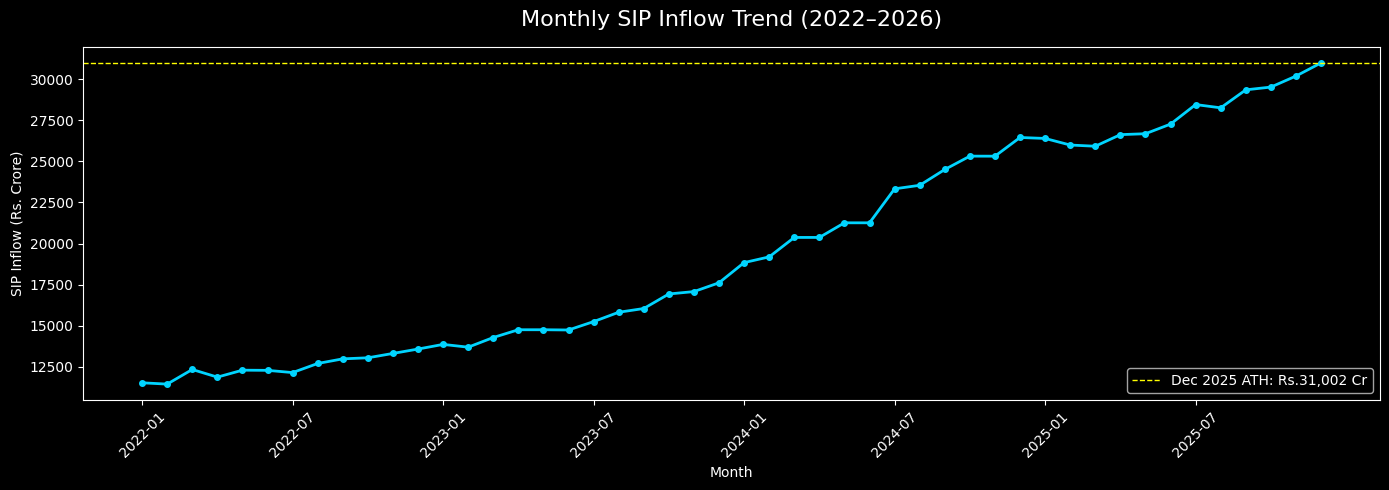

✅ Chart 1 saved!


In [ ]:
# Chart 1: Systematic Investment Plan Inflow Trend
plt.figure(figsize=(14, 5))
plt.plot(sip["month"], sip["sip_inflow_crore"], color="#00d4ff", linewidth=2, marker="o", markersize=4)
plt.title("Monthly SIP Inflow Trend (2022–2026)", fontsize=16, pad=15)
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Rs. Crore)")
plt.xticks(sip["month"][::6], rotation=45)
plt.axhline(y=31002, color="yellow", linestyle="--", linewidth=1, label="Dec 2025 ATH: Rs.31,002 Cr")
plt.legend()
plt.tight_layout()
plt.savefig(PROC_DIR.parent.parent / "reports" / "chart1_sip_trend.png", dpi=150)
plt.show()
print("✅ Chart 1 saved!")

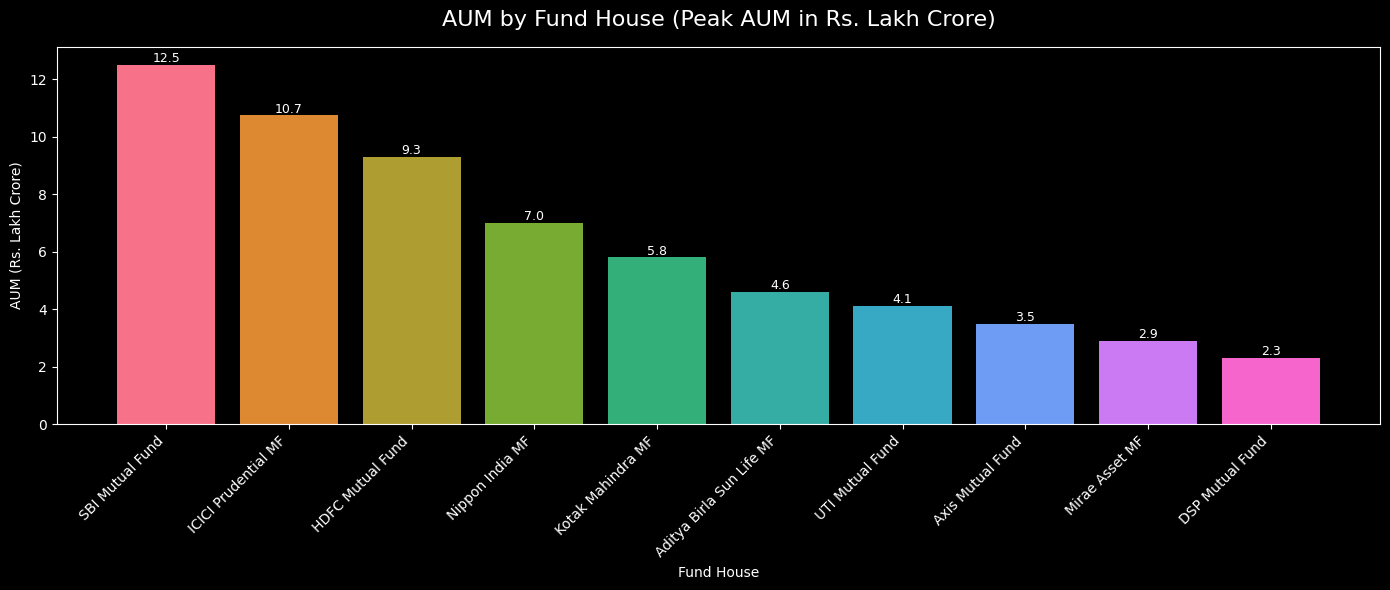

✅ Chart 2 saved!


In [ ]:
# Chart 2: Assets Under Management by Fund House (Bar Chart)
plt.figure(figsize=(14, 6))
aum_latest = aum.groupby("fund_house")["aum_crore"].max().sort_values(ascending=False)
bars = plt.bar(aum_latest.index, aum_latest.values / 1e5, color=sns.color_palette("husl", len(aum_latest)))
plt.title("AUM by Fund House (Peak AUM in Rs. Lakh Crore)", fontsize=16, pad=15)
plt.xlabel("Fund House")
plt.ylabel("AUM (Rs. Lakh Crore)")
plt.xticks(rotation=45, ha="right")
for bar, val in zip(bars, aum_latest.values / 1e5):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(PROC_DIR.parent.parent / "reports" / "chart2_aum_by_fundhouse.png", dpi=150)
plt.show()
print("✅ Chart 2 saved!")

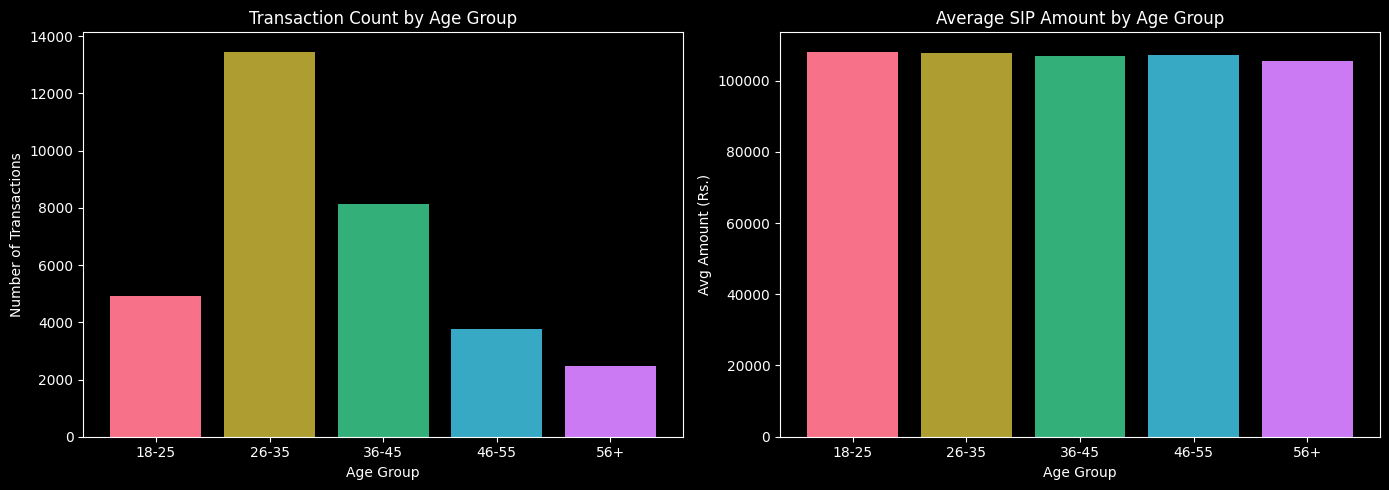

✅ Chart 3 saved!


In [6]:
# Chart 3: Transactions by Age Group
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

age_count = tx.groupby("age_group")["amount_inr"].agg(["count", "mean"]).reset_index()
age_count.columns = ["age_group", "count", "avg_amount"]
age_order = ["18-25", "26-35", "36-45", "46-55", "56+"]
age_count = age_count.set_index("age_group").reindex(age_order).reset_index()

# Count
ax1.bar(age_count["age_group"], age_count["count"], color=sns.color_palette("husl", 5))
ax1.set_title("Transaction Count by Age Group")
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Number of Transactions")

# Avg Amount
ax2.bar(age_count["age_group"], age_count["avg_amount"], color=sns.color_palette("husl", 5))
ax2.set_title("Average SIP Amount by Age Group")
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Avg Amount (Rs.)")

plt.tight_layout()
plt.savefig(PROC_DIR.parent.parent / "reports" / "chart3_age_analysis.png", dpi=150)
plt.show()
print("✅ Chart 3 saved!")

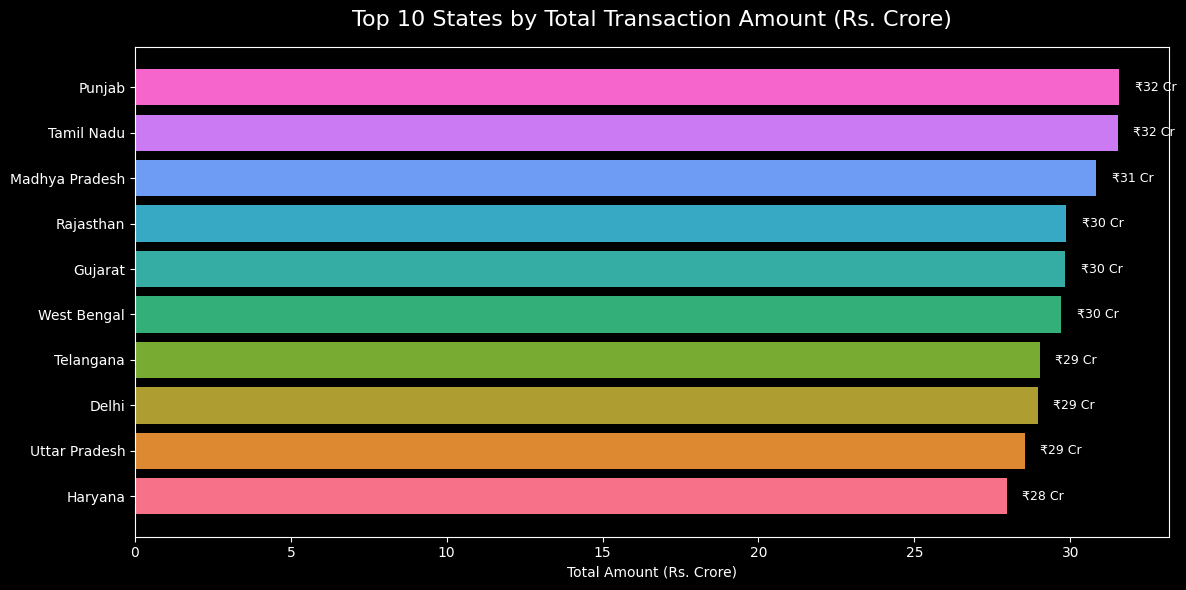

✅ Chart 4 saved!


In [7]:
# Chart 4: Top 10 States by Transaction Amount
state_data = tx.groupby("state")["amount_inr"].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(state_data.index, state_data.values / 1e7,
                color=sns.color_palette("husl", len(state_data)))
plt.title("Top 10 States by Total Transaction Amount (Rs. Crore)", fontsize=16, pad=15)
plt.xlabel("Total Amount (Rs. Crore)")
for bar, val in zip(bars, state_data.values / 1e7):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"₹{val:.0f} Cr", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(PROC_DIR.parent.parent / "reports" / "chart4_state_analysis.png", dpi=150)
plt.show()
print("✅ Chart 4 saved!")

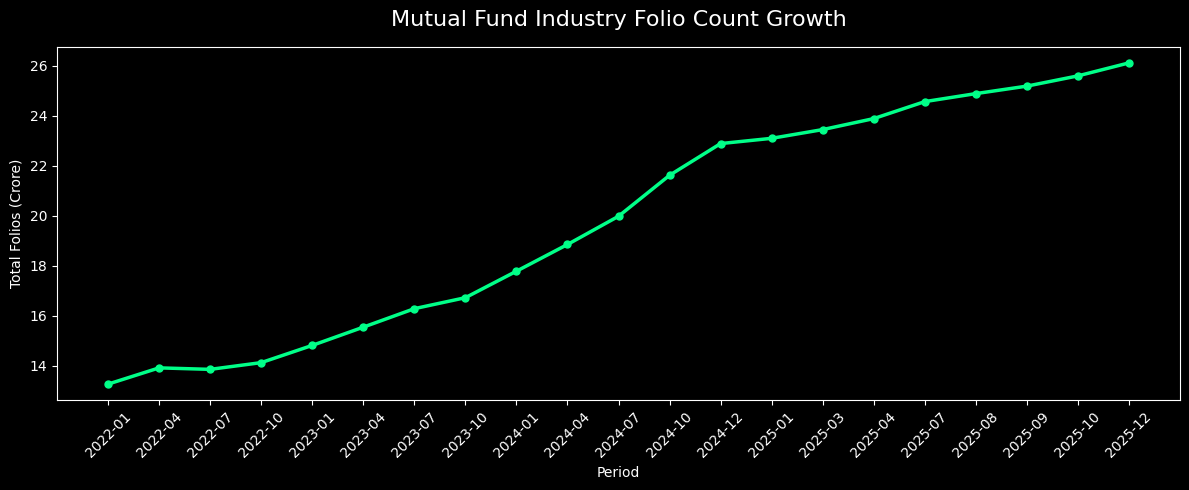

✅ Chart 5 saved!


In [8]:
# Chart 5: Industry Folio Count Growth
plt.figure(figsize=(12, 5))
plt.plot(folio.iloc[:, 0], folio.iloc[:, 1],
         color="#00ff88", linewidth=2.5, marker="o", markersize=5)
plt.title("Mutual Fund Industry Folio Count Growth", fontsize=16, pad=15)
plt.xlabel("Period")
plt.ylabel("Total Folios (Crore)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PROC_DIR.parent.parent / "reports" / "chart5_folio_growth.png", dpi=150)
plt.show()
print("✅ Chart 5 saved!")

In [9]:
# Chart 6: Top 10 Funds by Sharpe Ratio
print("Columns in perf:", perf.columns.tolist())
print("Columns in fund:", fund.columns.tolist())

Columns in perf: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
Columns in fund: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


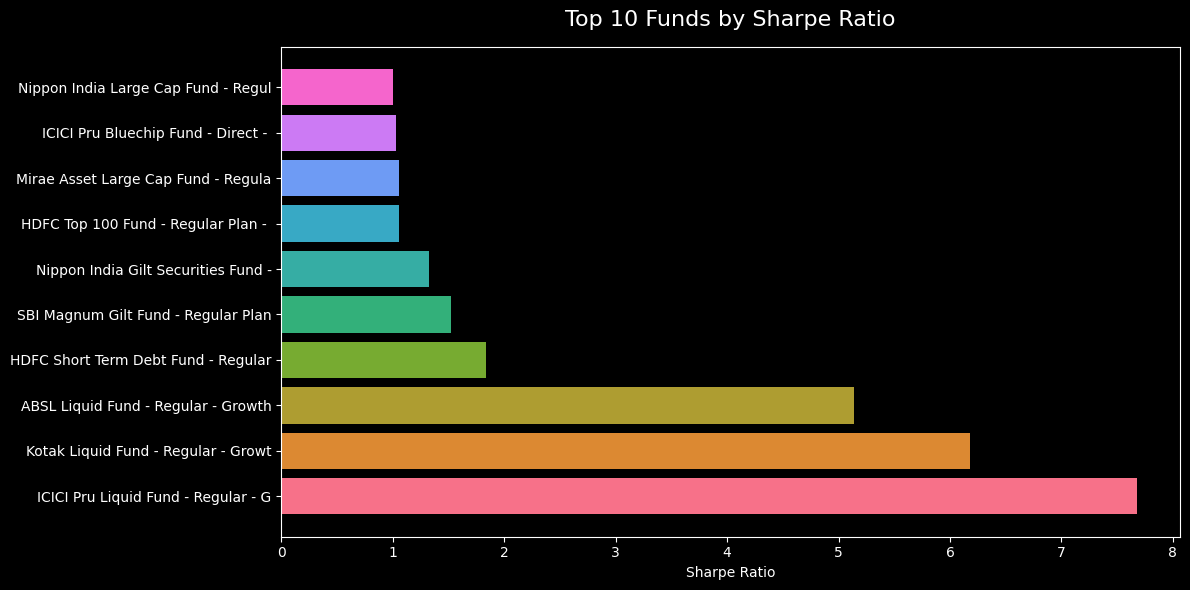

✅ Chart 6 saved!


In [10]:
# Chart 6: Top 10 Funds by Sharpe Ratio
top_sharpe = perf.nlargest(10, "sharpe_ratio")[["scheme_name", "sharpe_ratio"]]

plt.figure(figsize=(12, 6))
plt.barh(top_sharpe["scheme_name"].str[:35], top_sharpe["sharpe_ratio"],
         color=sns.color_palette("husl", 10))
plt.title("Top 10 Funds by Sharpe Ratio", fontsize=16, pad=15)
plt.xlabel("Sharpe Ratio")
plt.tight_layout()
plt.savefig(PROC_DIR.parent.parent / "reports" / "chart6_sharpe_ratio.png", dpi=150)
plt.show()
print("✅ Chart 6 saved!")

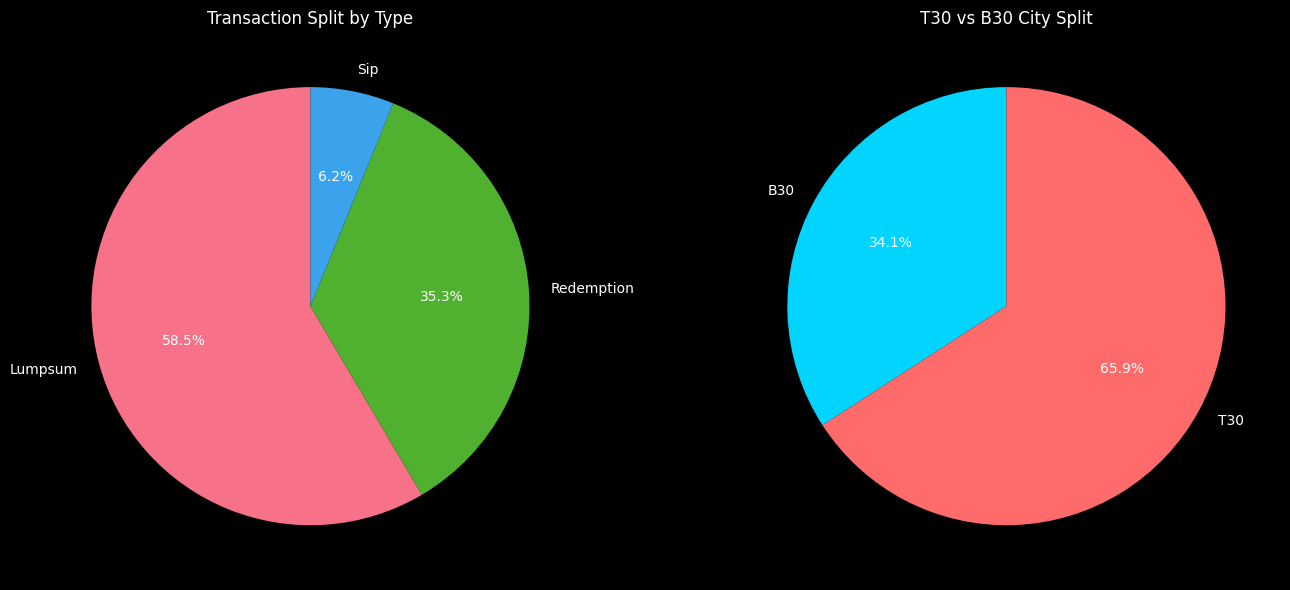

✅ Charts 7 & 8 saved!


In [11]:
# Chart 7: Transaction Type Split (Pie)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

tx_type = tx.groupby("transaction_type")["amount_inr"].sum()
ax1.pie(tx_type.values, labels=tx_type.index, autopct="%1.1f%%",
        colors=sns.color_palette("husl", len(tx_type)), startangle=90)
ax1.set_title("Transaction Split by Type")

# Chart 8: T30 vs B30
tier = tx.groupby("city_tier")["amount_inr"].sum()
ax2.pie(tier.values, labels=tier.index, autopct="%1.1f%%",
        colors=["#00d4ff", "#ff6b6b"], startangle=90)
ax2.set_title("T30 vs B30 City Split")

plt.tight_layout()
plt.savefig(PROC_DIR.parent.parent / "reports" / "chart7_8_pie_charts.png", dpi=150)
plt.show()
print("✅ Charts 7 & 8 saved!")

In [12]:
# EDA Key Findings Summary
findings = """
## EDA Key Findings

1. SIP inflows grew from Rs.12,000 Cr (Jan 2022) to Rs.31,002 Cr (Dec 2025) — 2.5x growth in 3 years
2. SBI Mutual Fund dominates with Rs.12.5 lakh crore AUM — largest AMC in India
3. 26-35 age group has highest transaction count (13,000+) — young professionals drive MF growth
4. Industry folio count doubled from 13.3 crore to 26 crore between 2022-2025
5. Lumpsum transactions dominate at 58.5% of total value vs SIP at only 6.2%
6. T30 cities contribute 65.9% of total transaction value vs B30 at 34.1%
7. ICICI Pru Liquid Fund has highest Sharpe ratio (~7.7) — liquid funds most risk-efficient
8. Punjab and Tamil Nadu lead in state-wise transaction amounts at Rs.32 Cr each
9. Average SIP amount is consistent across all age groups at ~Rs.1 lakh
10. Equity category dominates with 12 sub-categories vs Debt with fewer options
"""
print(findings)


## EDA Key Findings

1. SIP inflows grew from Rs.12,000 Cr (Jan 2022) to Rs.31,002 Cr (Dec 2025) — 2.5x growth in 3 years
2. SBI Mutual Fund dominates with Rs.12.5 lakh crore AUM — largest AMC in India
3. 26-35 age group has highest transaction count (13,000+) — young professionals drive MF growth
4. Industry folio count doubled from 13.3 crore to 26 crore between 2022-2025
5. Lumpsum transactions dominate at 58.5% of total value vs SIP at only 6.2%
6. T30 cities contribute 65.9% of total transaction value vs B30 at 34.1%
7. ICICI Pru Liquid Fund has highest Sharpe ratio (~7.7) — liquid funds most risk-efficient
8. Punjab and Tamil Nadu lead in state-wise transaction amounts at Rs.32 Cr each
9. Average SIP amount is consistent across all age groups at ~Rs.1 lakh
10. Equity category dominates with 12 sub-categories vs Debt with fewer options



In [ ]:
# Chart 9: Net Asset Value Trend (Overall Average across all schemes)
import plotly.graph_objects as go

nav_avg = nav.groupby("date")["nav"].mean().reset_index()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=nav_avg["date"],
    y=nav_avg["nav"],
    mode="lines",
    name="Average NAV",
    line=dict(color="#00d4ff", width=2)
))

fig.update_layout(
    title="Average NAV Trend Across All Schemes (2022–2026)",
    xaxis_title="Date",
    yaxis_title="Average NAV (Rs.)",
    template="plotly_dark",
    height=500
)
fig.write_image(str(PROC_DIR.parent.parent / "reports" / "chart9_nav_trend.png"),
                width=1400, height=500)
fig.show()
print("✅ Chart 9 saved!")

✅ Chart 9 saved!


In [16]:
# Chart 10: Category Inflow Heatmap
print("Category inflow columns:", cat.columns.tolist())
print(cat.head(3))

Category inflow columns: ['month', 'category', 'net_inflow_crore']
     month   category  net_inflow_crore
0  2024-04  Large Cap            2413.0
1  2024-04    Mid Cap            3897.0
2  2024-04  Small Cap            3533.0


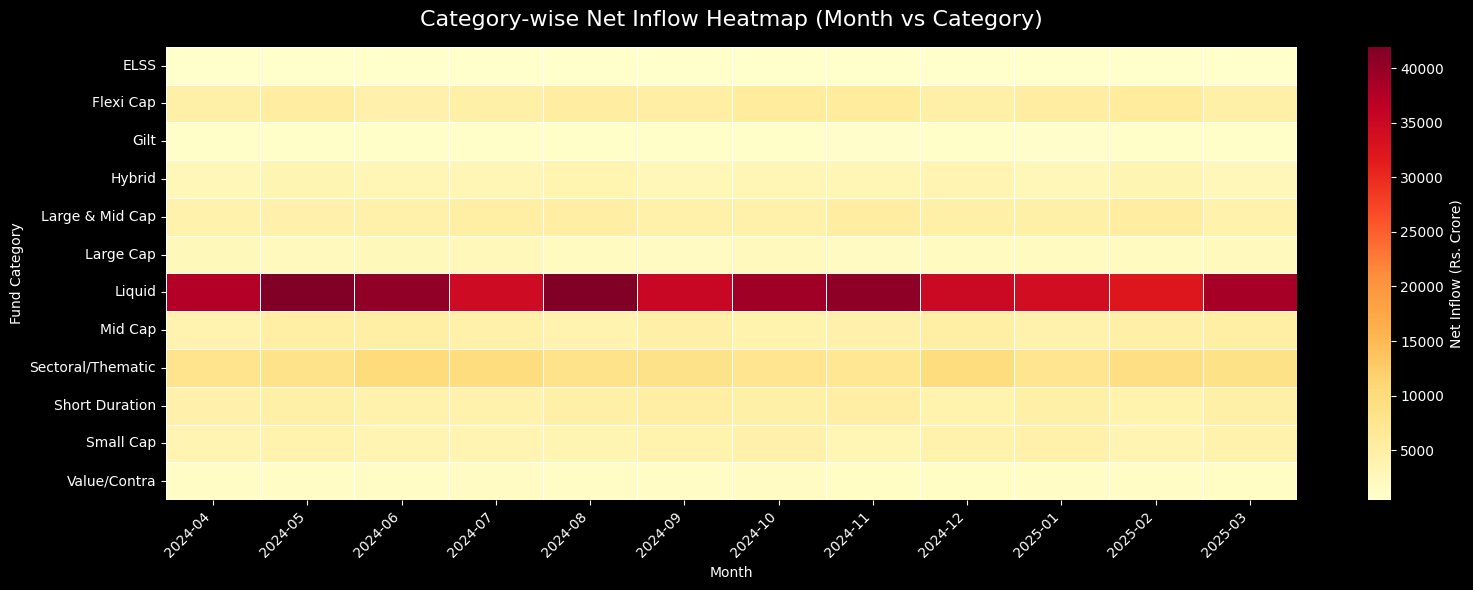

✅ Chart 10 saved!


In [17]:
# Chart 10: Category Inflow Heatmap
pivot = cat.pivot_table(index="category", columns="month", values="net_inflow_crore")

plt.figure(figsize=(16, 6))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.5, fmt=".0f",
            annot=False, cbar_kws={"label": "Net Inflow (Rs. Crore)"})
plt.title("Category-wise Net Inflow Heatmap (Month vs Category)", fontsize=16, pad=15)
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(PROC_DIR.parent.parent / "reports" / "chart10_category_heatmap.png", dpi=150)
plt.show()
print("✅ Chart 10 saved!")

In [18]:
# Chart 11: NAV Return Correlation Matrix
# Check columns in nav
print(nav.columns.tolist())
print(nav.head(3))

['date', 'nav']
        date       nav
0 2022-01-03  520.4608
1 2022-01-04  515.0971
2 2022-01-05  521.7239


C:\Users\KowshikAthreya\AppData\Local\Temp\ipykernel_20804\4284064805.py:12: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat(dfs, axis=1).sort_index()


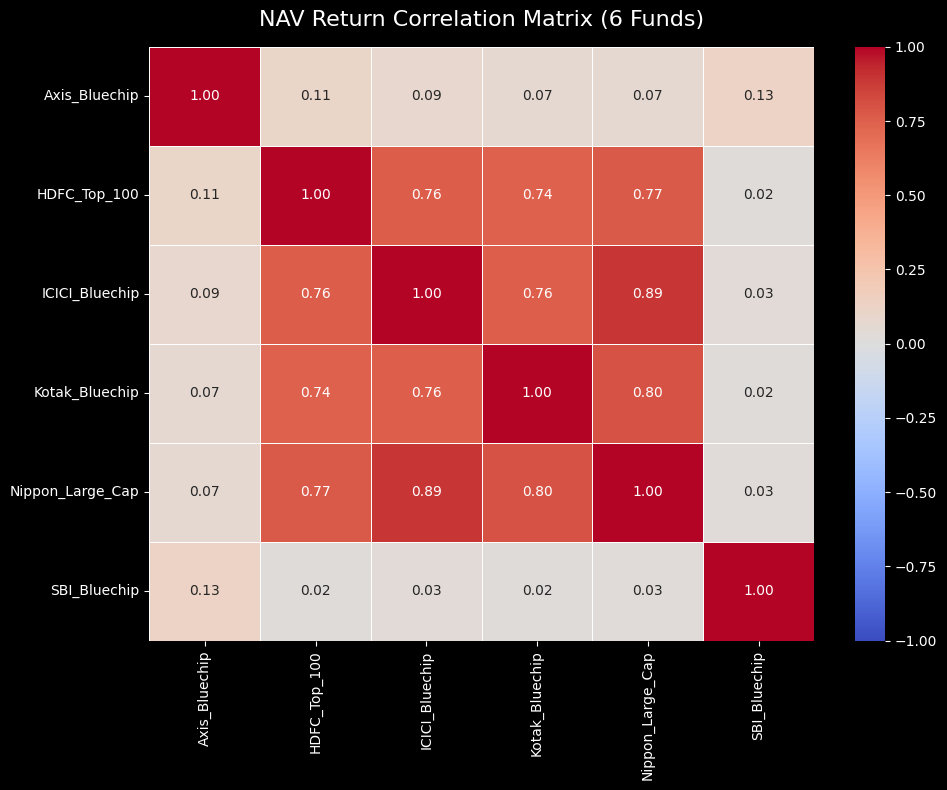

✅ Chart 11 saved!


In [19]:
# Chart 11: NAV Return Correlation Matrix (6 Live Funds)
import glob

live_files = list((PROC_DIR.parent / "raw").glob("live_nav_*.csv"))
dfs = []
for f in live_files:
    df = pd.read_csv(f, parse_dates=["date"])
    scheme = f.stem.replace("live_nav_", "")
    df = df[["date", "nav"]].rename(columns={"nav": scheme})
    dfs.append(df.set_index("date"))

combined = pd.concat(dfs, axis=1).sort_index()
returns = combined.pct_change().dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("NAV Return Correlation Matrix (6 Funds)", fontsize=16, pad=15)
plt.tight_layout()
plt.savefig(PROC_DIR.parent.parent / "reports" / "chart11_correlation_matrix.png", dpi=150)
plt.show()
print("✅ Chart 11 saved!")

In [20]:
# Chart 12: Sector Allocation Donut Chart
print("Portfolio columns:", port.columns.tolist())
print(port.head(3))

Portfolio columns: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol              stock_name       sector  weight_pct  \
0     119551    POWERGRID  Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK           HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM   Grasim Industries Ltd  Diversified        9.90   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  


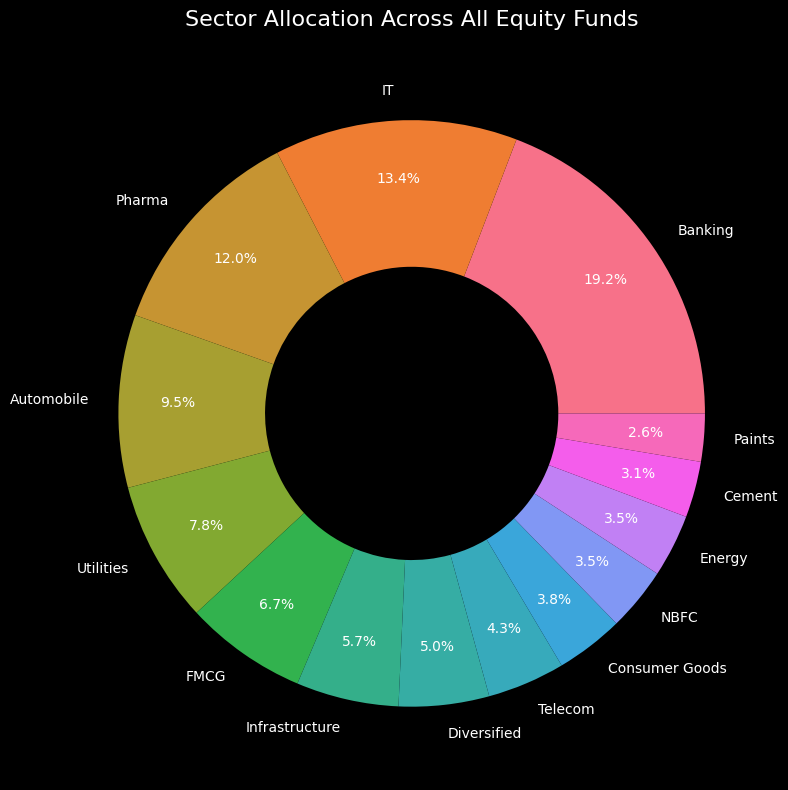

✅ Chart 12 saved!


In [21]:
# Chart 12: Sector Allocation Donut Chart
sector_weights = port.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    sector_weights.values,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    pctdistance=0.8,
    colors=sns.color_palette("husl", len(sector_weights)),
    wedgeprops=dict(width=0.5)
)
ax.set_title("Sector Allocation Across All Equity Funds", fontsize=16, pad=15)
plt.tight_layout()
plt.savefig(PROC_DIR.parent.parent / "reports" / "chart12_sector_donut.png", dpi=150)
plt.show()
print("✅ Chart 12 saved!")